In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import pingouin as pg
import sys

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Matplotlib": plt.matplotlib.__version__,
    "Seaborn": sns.__version__,
    "Statsmodels": sm.__version__,
    "Pingouin": pg.__version__
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
df_versions

,Library,Version
0,Python,3.13.9
1,Pandas,2.3.3
2,NumPy,2.3.4
3,Matplotlib,3.10.7
4,Seaborn,0.13.2
5,Statsmodels,0.14.5
6,Pingouin,0.5.5


## Read Data

In [2]:
# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# reset options
# pd.reset_option('display.max_columns')

In [3]:
# load using pyarrow for performance (crime data is joined between crime & neighborhood & police using geom)
df_crime = pd.read_csv("../Data/chicago_crimes_export.csv", engine="pyarrow", dtype_backend="pyarrow")
df_arrest = pd.read_csv("../Data/chicago_arrests_export.csv", engine="pyarrow", dtype_backend="pyarrow")

In [4]:
df_crime.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
case_number,8353122,8352516,HZ140230,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,8353122,NaN,NaN,NaN,2011-07-31 14:09:03,2001-01-01 00:00:00,2005-06-14 21:30:00,2010-06-05 04:42:00,2017-05-08 09:19:15,2025-12-24 00:00:00,NaN
block,8353122,63692,001XX N STATE ST,16996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iucr,8353122,416,0820,671522,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_type,8353122,34,THEFT,1769511,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,8353122,565,SIMPLE,988659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_description,8343134,218,STREET,2194409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrest,8353122,2,f,6247440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
domestic,8353122,2,f,6905712,NaN,NaN,NaN,NaN,NaN,NaN,NaN
beat,8353122.0,<NA>,<NA>,<NA>,1181.414643,111.0,621.0,1034.0,1731.0,2535.0,703.134414


In [5]:
df_crime.shape

(8353122, 23)

In [6]:
print(f'Police District (Police): {df_crime.p_district.nunique()}')
print(f'Police Sector (Police): {df_crime.p_sector.nunique()}')
print(f'Beat (Police): {df_crime.p_beat.nunique()}')

Police District (Police): 22
Police Sector (Police): 4
Beat (Police): 274


In [7]:
print(f'Police beats (Crime): {df_crime.beat.nunique()}')
print(f'Police District(Crime): {df_crime.district.nunique()}')
print(f'Ward (Crime): {df_crime.ward.nunique()}')

Police beats (Crime): 304
Police District(Crime): 24
Ward (Crime): 50


## Check Data

In [8]:
print(f"Beat Difference: {(df_crime.beat != df_crime.p_beat).sum():,}")
print(f"District Difference: {(df_crime.district != df_crime.p_district).sum():,}")

Beat Difference: 1,572,683
District Difference: 124,361


## Data Wrangle

In [9]:
# num of rows before 
before = df_crime.shape[0]
# remove any duplicates
df_crime = df_crime.drop_duplicates().reset_index(drop=True)
# num of rows after 
after = df_crime.shape[0]
print("Duplicate Rows Removed:", before - after)
print("Shape:", df_crime.shape)

Duplicate Rows Removed: 179
Shape: (8352943, 23)


In [10]:
# remove columns
drop_columns = ['case_number', 'community_area', 'block', 'iucr', 'secondary_neighborhood', 'p_beat', 'p_district','updated_on']
# new dataframe
df = df_crime.drop(columns=drop_columns)
# display
df.head()

,date,primary_type,description,location_description,arrest,domestic,beat,district,ward,year,zip_code,zip_code_area,primary_neighborhood,neighborhood_area,p_sector
0,2012-08-02 09:30:00,BATTERY,SIMPLE,BAR OR TAVERN,f,f,122,1,2,2012,60607,64664294.2344,Loop,31485185.0318,2
1,2012-07-23 12:20:00,CRIMINAL TRESPASS,TO LAND,OTHER,t,f,122,1,2,2012,60607,64664294.2344,Loop,31485185.0318,2
2,2012-05-01 22:00:00,THEFT,FROM BUILDING,BAR OR TAVERN,f,f,122,1,2,2012,60607,64664294.2344,Loop,31485185.0318,2
3,2011-10-27 09:25:00,CRIMINAL TRESPASS,TO LAND,OTHER,t,f,131,1,2,2011,60607,64664294.2344,Loop,31485185.0318,2
4,2011-08-30 11:05:00,CRIMINAL TRESPASS,TO LAND,OTHER,t,f,131,1,2,2011,60607,64664294.2344,Loop,31485185.0318,2


In [11]:
# display number of unique values
for i in df.columns:
    print(f"{i}: {df[i].nunique():,}")

date: 3,518,287
primary_type: 34
description: 565
location_description: 218
arrest: 2
domestic: 2
beat: 304
district: 24
ward: 50
year: 25
zip_code: 59
zip_code_area: 59
primary_neighborhood: 98
neighborhood_area: 98
p_sector: 4


In [22]:
# # aggregate data
aggregate_anova = df.groupby(['year','primary_type', 'primary_neighborhood']).size().unstack().fillna(0)
aggregate_anova.head()

primary_neighborhood      Albany Park  Andersonville  Archer Heights  \
year primary_type                                                      
2001 ARSON                       12.0            1.0             3.0   
     ASSAULT                    232.0           35.0            76.0   
     BATTERY                    802.0           76.0           222.0   
     BURGLARY                   245.0           59.0           119.0   
     CRIM SEXUAL ASSAULT         18.0            0.0             4.0   

primary_neighborhood      Armour Square  Ashburn  Auburn Gresham  Austin  \
year primary_type                                                          
2001 ARSON                          4.0      8.0            14.0    72.0   
     ASSAULT                       55.0    276.0           879.0  1695.0   
     BATTERY                      210.0    674.0          2796.0  5594.0   
     BURGLARY                      58.0    249.0           811.0   936.0   
     CRIM SEXUAL ASSAULT            3.0     12.0            51.0   136.0   

primary_neighborhood      Avalon Park  Avondale  Belmont Cragin  Beverly  \
year primary_type                                                          
2001 ARSON                        3.0      18.0            27.0      1.0   
     ASSAULT                    167.0     280.0           565.0    116.0   
     BATTERY                    430.0     754.0          1379.0    212.0   
     BURGLARY                   122.0     420.0           669.0    138.0   
     CRIM SEXUAL ASSAULT          5.0      14.0            19.0      3.0   

primary_neighborhood      Boystown  Bridgeport  Brighton Park  Bucktown  \
year primary_type                                                         
2001 ARSON                     1.0        20.0           15.0       4.0   
     ASSAULT                  23.0       185.0          258.0     112.0   
     BATTERY                  71.0       546.0          757.0     216.0   
     BURGLARY                 26.0       331.0          397.0     275.0   
     CRIM SEXUAL ASSAULT       0.0         5.0           10.0       9.0   

primary_neighborhood      Burnside  Calumet Heights  Chatham  Chicago Lawn  \
year primary_type                                                            
2001 ARSON                     7.0              6.0     18.0          29.0   
     ASSAULT                  59.0            197.0    567.0         667.0   
     BATTERY                 165.0            426.0   1585.0        2155.0   
     BURGLARY                 26.0            161.0    529.0         826.0   
     CRIM SEXUAL ASSAULT       7.0              9.0     38.0          50.0   

primary_neighborhood      Chinatown  Clearing  Douglas  Dunning  East Side  \
year primary_type                                                            
2001 ARSON                      0.0       9.0      6.0      4.0        6.0   
     ASSAULT                   32.0     106.0    509.0    167.0      182.0   
     BATTERY                   67.0     260.0   1765.0    419.0      466.0   
     BURGLARY                  33.0     154.0    177.0    204.0      145.0   
     CRIM SEXUAL ASSAULT        1.0       5.0     35.0      8.0        4.0   

primary_neighborhood      East Village  Edgewater  Edison Park  Englewood  \
year primary_type                                                           
2001 ARSON                         4.0       10.0          1.0       73.0   
     ASSAULT                      63.0      304.0         25.0     2159.0   
     BATTERY                     162.0      865.0         66.0     7130.0   
     BURGLARY                    132.0      284.0         33.0     1380.0   
     CRIM SEXUAL ASSAULT           1.0       22.0          1.0      134.0   

primary_neighborhood      Fuller Park  Gage Park  Galewood  Garfield Park  \
year primary_type                                                           
2001 ARSON                        2.0       12.0       1.0           29.0   
     ASSAULT                    106.0 

In [23]:
aggregate_anova.index

MultiIndex([(2001,                    'ARSON'),
            (2001,                  'ASSAULT'),
            (2001,                  'BATTERY'),
            (2001,                 'BURGLARY'),
            (2001,      'CRIM SEXUAL ASSAULT'),
            (2001,          'CRIMINAL DAMAGE'),
            (2001,  'CRIMINAL SEXUAL ASSAULT'),
            (2001,        'CRIMINAL TRESPASS'),
            (2001,       'DECEPTIVE PRACTICE'),
            (2001,        'DOMESTIC VIOLENCE'),
            ...
            (2025, 'OTHER NARCOTIC VIOLATION'),
            (2025,            'OTHER OFFENSE'),
            (2025,             'PROSTITUTION'),
            (2025,         'PUBLIC INDECENCY'),
            (2025,   'PUBLIC PEACE VIOLATION'),
            (2025,                  'ROBBERY'),
            (2025,              'SEX OFFENSE'),
            (2025,                 'STALKING'),
            (2025,                    'THEFT'),
            (2025,        'WEAPONS VIOLATION')],
           names=['year

In [26]:
aggregate_anova.loc[2025]

primary_neighborhood,Albany Park,Andersonville,Archer Heights,Armour Square,Ashburn,Auburn Gresham,Austin,Avalon Park,Avondale,Belmont Cragin,Beverly,Boystown,Bridgeport,Brighton Park,Bucktown,Burnside,Calumet Heights,Chatham,Chicago Lawn,Chinatown,Clearing,Douglas,Dunning,East Side,East Village,Edgewater,Edison Park,Englewood,Fuller Park,Gage Park,Galewood,Garfield Park,Garfield Ridge,Gold Coast,Grand Boulevard,Grand Crossing,Grant Park,Greektown,Hegewisch,Hermosa,Humboldt Park,Hyde Park,Irving Park,Jackson Park,Jefferson Park,Kenwood,Lake View,Lincoln Park,Lincoln Square,"Little Italy, UIC",Little Village,Logan Square,Loop,Lower West Side,Magnificent Mile,Mckinley Park,Millenium Park,Montclare,Morgan Park,Mount Greenwood,Museum Campus,Near South Side,New City,North Center,North Lawndale,North Park,Norwood Park,O'Hare,Oakland,Old Town,Portage Park,Printers Row,Pullman,River North,Riverdale,Rogers Park,Roseland,Rush & Division,"Sauganash,Forest Glen",Sheffield & DePaul,South Chicago,South Deering,South Shore,Streeterville,Ukrainian Village,United Center,Uptown,Washington Heights,Washington Park,West Elsdon,West Lawn,West Loop,West Pullman,West Ridge,West Town,Wicker Park,Woodlawn,Wrigleyville
primary_type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ARSON,2.0,0.0,0.0,0.0,4.0,14.0,30.0,3.0,3.0,2.0,1.0,0.0,2.0,3.0,0.0,1.0,3.0,9.0,15.0,0.0,2.0,1.0,4.0,2.0,0.0,4.0,1.0,20.0,2.0,5.0,1.0,8.0,5.0,0.0,2.0,16.0,1.0,0.0,1.0,6.0,11.0,0.0,2.0,0.0,0.0,5.0,1.0,0.0,2.0,2.0,6.0,5.0,11.0,4.0,0.0,3.0,0.0,1.0,1.0,0.0,1.0,0.0,12.0,1.0,11.0,0.0,2.0,0.0,0.0,1.0,4.0,1.0,1.0,3.0,5.0,6.0,8.0,0.0,0.0,1.0,12.0,3.0,14.0,0.0,0.0,2.0,5.0,1.0,4.0,5.0,2.0,6.0,15.0,2.0,3.0,3.0,5.0,0.0
ASSAULT,203.0,26.0,72.0,71.0,205.0,674.0,1102.0,110.0,135.0,357.0,73.0,24.0,184.0,189.0,38.0,28.0,142.0,554.0,537.0,36.0,110.0,281.0,111.0,158.0,22.0,229.0,20.0,1065.0,57.0,194.0,34.0,747.0,155.0,24.0,326.0,739.0,14.0,29.0,55.0,101.0,572.0,148.0,179.0,22.0,81.0,188.0,243.0,153.0,144.0,323.0,402.0,264.0,414.0,261.0,23.0,75.0,13.0,50.0,159.0,42.0,10.0,179.0,420.0,79.0,622.0,68.0,90.0,73.0,70.0,128.0,221.0,20.0,120.0,294.0,166.0,292.0,542.0,76.0,22.0,32.0,388.0,195.0,930.0,107.0,43.0,256.0,381.0,268.0,301.0,75.0,128.0,271.0,333.0,247.0,131.0,112.0,388.0,37.0
BATTERY,405.0,39.0,137.0,105.0,373.0,1231.0,2490.0,185.0,294.0,743.0,142.0,74.0,245.0,408.0,79.0,60.0,242.0,983.0,1003.0,70.0,200.0,485.0,245.0,256.0,33.0,438.0,36.0,2115.0,107.0,399.0,55.0,1540.0,291.0,80.0,558.0,1307.0,43.0,27.0,116.0,197.0,1335.0,259.0,377.0,60.0,164.0,328.0,539.0,224.0,285.0,514.0,838.0,445.0,996.0,528.0,74.0,139.0,27.0,107.0,344.0,89.0,38.0,348.0,778.0,126.0,1371.0,151.0,154.0,212.0,138.0,236.0,460.0,32.0,182.0,703.0,273.0,723.0,1036.0,193.0,49.0,68.0,747.0,329.0,1759.0,277.0,90.0,404.0,768.0,443.0,565.0,170.0,252.0,519.0,588.0,575.0,265.0,209.0,748.0,118.0
BURGLARY,105.0,40.0,42.0,33.0,70.0,235.0,331.0,55.0,128.0,185.0,43.0,15.0,85.0,91.0,94.0,11.0,54.0,225.0,137.0,14.0,46.0,91.0,88.0,39.0,30.0,128.0,28.0,260.0,16.0,74.0,25.0,169.0,71.0,7.0,112.0,200.0,13.0,7.0,25.0,36.0,218.0,99.0,164.0,17.0,47.0,75.0,270.0,206.0,95.0,130.0,108.0,199.0,157.0,112.0,7.0,54.0,1.0,45.0,53.0,20.0,1.0,97.0,144.0,100.0,110.0,64.0,100.0,18.0,18.0,63.0,168.0,14.0,22.0,186.0,20.0,133.0,172.0,10.0,50.0,33.0,157.0,54.0,349.0,33.0,24.0,75.0,204.0,107.0,57.0,35.0,64.0,271.0,165.0,198.0,305.0,119.0,134.0,27.0
CONCEALED CARRY LICENSE VIOLATION,0.0,0.0,1.0,0.0,1.0,3.0,7.0,1.0,1.0,6.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,4.0,1.0,1.0,3.0,1.0,0.0,2.0,1.0,0.0,7.0,0.0,0.0,1.0,4.0,24.0,1.0,2.0,9.0,1.0,1.0,0.0,1.0,4.0,1.0,1.0,2.0,0.0,0.0,7.0,0.0,0.0,9.0,7.0,4.0,11.0,5.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,4.0,4.0,0.0,19.0,0.0,0.0,55.0,0.0,1.0,2.0,0.0,0.0,3.0,0.0,1.0,4.0,0.0,0.0,0.0,2.0,0.0,3.0,0.0,0.0,4.0,0.0,3.0,1.0,1.0,3.0,3.0,3.0,1.0,3.0,0.0,4.0,0.0
CRIMINAL DAMAGE,295.0,42.0,83.0,94.0,232.0,862.0,1145.0,153.0,216.0,410.0,110.0,30.0,214.0,246.0,179.0,35.0,213.0,615.0,525.0,49.0,137.0,334.0,162.0,215.0,4

In [44]:
aggregate_anova.loc[2025].loc[['ROBBERY', 'PROSTITUTION']]

primary_neighborhood,Albany Park,Andersonville,Archer Heights,Armour Square,Ashburn,Auburn Gresham,Austin,Avalon Park,Avondale,Belmont Cragin,Beverly,Boystown,Bridgeport,Brighton Park,Bucktown,Burnside,Calumet Heights,Chatham,Chicago Lawn,Chinatown,Clearing,Douglas,Dunning,East Side,East Village,Edgewater,Edison Park,Englewood,Fuller Park,Gage Park,Galewood,Garfield Park,Garfield Ridge,Gold Coast,Grand Boulevard,Grand Crossing,Grant Park,Greektown,Hegewisch,Hermosa,Humboldt Park,Hyde Park,Irving Park,Jackson Park,Jefferson Park,Kenwood,Lake View,Lincoln Park,Lincoln Square,"Little Italy, UIC",Little Village,Logan Square,Loop,Lower West Side,Magnificent Mile,Mckinley Park,Millenium Park,Montclare,Morgan Park,Mount Greenwood,Museum Campus,Near South Side,New City,North Center,North Lawndale,North Park,Norwood Park,O'Hare,Oakland,Old Town,Portage Park,Printers Row,Pullman,River North,Riverdale,Rogers Park,Roseland,Rush & Division,"Sauganash,Forest Glen",Sheffield & DePaul,South Chicago,South Deering,South Shore,Streeterville,Ukrainian Village,United Center,Uptown,Washington Heights,Washington Park,West Elsdon,West Lawn,West Loop,West Pullman,West Ridge,West Town,Wicker Park,Woodlawn,Wrigleyville
primary_type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ROBBERY,48.0,2.0,23.0,33.0,34.0,162.0,338.0,29.0,39.0,89.0,14.0,15.0,26.0,37.0,30.0,10.0,25.0,162.0,122.0,34.0,11.0,57.0,14.0,19.0,10.0,57.0,0.0,287.0,38.0,56.0,1.0,269.0,34.0,12.0,66.0,210.0,8.0,4.0,13.0,27.0,191.0,48.0,36.0,9.0,16.0,32.0,112.0,46.0,28.0,55.0,127.0,79.0,218.0,63.0,11.0,19.0,6.0,6.0,37.0,6.0,4.0,36.0,103.0,17.0,174.0,18.0,9.0,2.0,12.0,27.0,39.0,8.0,9.0,152.0,32.0,82.0,157.0,33.0,3.0,9.0,105.0,57.0,222.0,17.0,21.0,63.0,81.0,63.0,38.0,23.0,31.0,95.0,68.0,66.0,77.0,50.0,76.0,26.0
PROSTITUTION,13.0,0.0,0.0,1.0,0.0,0.0,46.0,0.0,1.0,5.0,0.0,0.0,1.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,5.0,0.0,0.0,0.0,8.0,70.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,3.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,1.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [43]:
aggregate_anova.loc[
    [(2024, 'ROBBERY'), (2024, 'PROSTITUTION'),
     (2025, 'ROBBERY'), (2025, 'PROSTITUTION')]
]


primary_neighborhood  Albany Park  Andersonville  Archer Heights  \
year primary_type                                                  
2024 ROBBERY                 72.0            2.0            38.0   
     PROSTITUTION             2.0            0.0             0.0   
2025 ROBBERY                 48.0            2.0            23.0   
     PROSTITUTION            13.0            0.0             0.0   

primary_neighborhood  Armour Square  Ashburn  Auburn Gresham  Austin  \
year primary_type                                                      
2024 ROBBERY                   38.0     49.0           231.0   610.0   
     PROSTITUTION               1.0      0.0             0.0   107.0   
2025 ROBBERY                   33.0     34.0           162.0   338.0   
     PROSTITUTION               1.0      0.0             0.0    46.0   

primary_neighborhood  Avalon Park  Avondale  Belmont Cragin  Beverly  \
year primary_type                                                      
2024 ROBBERY                 32.0      74.0           165.0     18.0   
     PROSTITUTION             0.0       0.0             3.0      0.0   
2025 ROBBERY                 29.0      39.0            89.0     14.0   
     PROSTITUTION             0.0       1.0             5.0      0.0   

primary_neighborhood  Boystown  Bridgeport  Brighton Park  Bucktown  Burnside  \
year primary_type                                                               
2024 ROBBERY              12.0        47.0           82.0      39.0      15.0   
     PROSTITUTION          0.0         1.0            0.0       0.0       0.0   
2025 ROBBERY              15.0        26.0           37.0      30.0      10.0   
     PROSTITUTION          0.0         1.0            3.0       1.0       0.0   

primary_neighborhood  Calumet Heights  Chatham  Chicago Lawn  Chinatown  \
year primary_type                                                         
2024 ROBBERY                     50.0    266.0         193.0       56.0   
     PROSTITUTION                 0.0      0.0           0.0        2.0   
2025 ROBBERY                     25.0    162.0         122.0       34.0   
     PROSTITUTION                 0.0      0.0           0.0        0.0   

primary_neighborhood  Clearing  Douglas  Dunning  East Side  East Village  \
year primary_type                                                           
2024 ROBBERY              19.0     76.0     20.0       22.0          25.0   
     PROSTITUTION          1.0      0.0      0.0        0.0           0.0   
2025 ROBBERY              11.0     57.0     14.0       19.0          10.0   
     PROSTITUTION          0.0      0.0      1.0        0.0           0.0   

primary_neighborhood  Edgewater  Edison Park  Englewood  Fuller Park  \
year primary_type                                                      
2024 ROBBERY               93.0          3.0      447.0         44.0   
     PROSTITUTION           0.0          0.0        0.0          0.0   
2025 ROBBERY               57.0          0.0      287.0         38.0   
     PROSTITUTION           1.0          0.0        5.0          0.0   

primary_neighborhood  Gage Park  Galewood  Garfield Park  Garfield Ridge  \
year primary_type                                                          
2024 ROBBERY              128.0       8.0          363.0            44.0   
     PROSTITUTION           0.0       0.0           39.0            81.0   
2025 ROBBERY               56.0       1.0          269.0            34.0   
     PROSTITUTION           0.0       0.0            8.0            70.0   

primary_neighborhood  Gold Coast  Grand Boulevard  Grand Crossing  Grant Park  \
year primary_type                                                               
2024 ROBBERY                23.0             83.0           272.0        12.0   
     PROSTITUTION            0.0              0.0             0.0         0.0   
2025 ROBBERY                12.0             66.0           210.0         8.0   
     PROSTITUTION            

In [48]:
aggregate_anova.loc[(slice(2023, 2025), ['ROBBERY', 'PROSTITUTION']), :]

primary_neighborhood  Albany Park  Andersonville  Archer Heights  \
year primary_type                                                  
2023 PROSTITUTION             0.0            0.0             0.0   
     ROBBERY                 88.0            4.0            57.0   
2024 PROSTITUTION             2.0            0.0             0.0   
     ROBBERY                 72.0            2.0            38.0   
2025 PROSTITUTION            13.0            0.0             0.0   
     ROBBERY                 48.0            2.0            23.0   

primary_neighborhood  Armour Square  Ashburn  Auburn Gresham  Austin  \
year primary_type                                                      
2023 PROSTITUTION               0.0      0.0             0.0    99.0   
     ROBBERY                   42.0     79.0           257.0   687.0   
2024 PROSTITUTION               1.0      0.0             0.0   107.0   
     ROBBERY                   38.0     49.0           231.0   610.0   
2025 PROSTITUTION               1.0      0.0             0.0    46.0   
     ROBBERY                   33.0     34.0           162.0   338.0   

primary_neighborhood  Avalon Park  Avondale  Belmont Cragin  Beverly  \
year primary_type                                                      
2023 PROSTITUTION             0.0       0.0             0.0      0.0   
     ROBBERY                 47.0     118.0           259.0     34.0   
2024 PROSTITUTION             0.0       0.0             3.0      0.0   
     ROBBERY                 32.0      74.0           165.0     18.0   
2025 PROSTITUTION             0.0       1.0             5.0      0.0   
     ROBBERY                 29.0      39.0            89.0     14.0   

primary_neighborhood  Boystown  Bridgeport  Brighton Park  Bucktown  Burnside  \
year primary_type                                                               
2023 PROSTITUTION          0.0         0.0            0.0       0.0       0.0   
     ROBBERY              17.0        61.0          165.0      85.0       6.0   
2024 PROSTITUTION          0.0         1.0            0.0       0.0       0.0   
     ROBBERY              12.0        47.0           82.0      39.0      15.0   
2025 PROSTITUTION          0.0         1.0            3.0       1.0       0.0   
     ROBBERY              15.0        26.0           37.0      30.0      10.0   

primary_neighborhood  Calumet Heights  Chatham  Chicago Lawn  Chinatown  \
year primary_type                                                         
2023 PROSTITUTION                 0.0      1.0           1.0        0.0   
     ROBBERY                    108.0    337.0         182.0       57.0   
2024 PROSTITUTION                 0.0      0.0           0.0        2.0   
     ROBBERY                     50.0    266.0         193.0       56.0   
2025 PROSTITUTION                 0.0      0.0           0.0        0.0   
     ROBBERY                     25.0    162.0         122.0       34.0   

primary_neighborhood  Clearing  Douglas  Dunning  East Side  East Village  \
year primary_type                                                           
2023 PROSTITUTION          0.0      0.0      0.0        0.0           0.0   
     ROBBERY              17.0     74.0     31.0       29.0          41.0   
2024 PROSTITUTION          1.0      0.0      0.0        0.0           0.0   
     ROBBERY              19.0     76.0     20.0       22.0          25.0   
2025 PROSTITUTION          0.0      0.0      1.0        0.0           0.0   
     ROBBERY              11.0     57.0     14.0       19.0          10.0   

primary_neighborhood  Edgewater  Edison Park  Englewood  Fuller Park  \
year primary_type                                                      
2023 PROSTITUTION           0.0          0.0       12.0          0.0   
     ROBBERY               64.0          4.0      399.0         23.0   
2024 PROSTITUTION           0.0          0.0        0.0          0.0   
     ROBBERY               93.0          3.0      447.0         44.0   
20

In [35]:
reset_agg_anova = aggregate_anova.reset_index()
reset_agg_anova.head()

primary_neighborhood,year,primary_type,Albany Park,Andersonville,Archer Heights,Armour Square,Ashburn,Auburn Gresham,Austin,Avalon Park,Avondale,Belmont Cragin,Beverly,Boystown,Bridgeport,Brighton Park,Bucktown,Burnside,Calumet Heights,Chatham,Chicago Lawn,Chinatown,Clearing,Douglas,Dunning,East Side,East Village,Edgewater,Edison Park,Englewood,Fuller Park,Gage Park,Galewood,Garfield Park,Garfield Ridge,Gold Coast,Grand Boulevard,Grand Crossing,Grant Park,Greektown,Hegewisch,Hermosa,Humboldt Park,Hyde Park,Irving Park,Jackson Park,Jefferson Park,Kenwood,Lake View,Lincoln Park,Lincoln Square,"Little Italy, UIC",Little Village,Logan Square,Loop,Lower West Side,Magnificent Mile,Mckinley Park,Millenium Park,Montclare,Morgan Park,Mount Greenwood,Museum Campus,Near South Side,New City,North Center,North Lawndale,North Park,Norwood Park,O'Hare,Oakland,Old Town,Portage Park,Printers Row,Pullman,River North,Riverdale,Rogers Park,Roseland,Rush & Division,"Sauganash,Forest Glen",Sheffield & DePaul,South Chicago,South Deering,South Shore,Streeterville,Ukrainian Village,United Center,Uptown,Washington Heights,Washington Park,West Elsdon,West Lawn,West Loop,West Pullman,West Ridge,West Town,Wicker Park,Woodlawn,Wrigleyville
0,2001,ARSON,12.0,1.0,3.0,4.0,8.0,14.0,72.0,3.0,18.0,27.0,1.0,1.0,20.0,15.0,4.0,7.0,6.0,18.0,29.0,0.0,9.0,6.0,4.0,6.0,4.0,10.0,1.0,73.0,2.0,12.0,1.0,29.0,7.0,0.0,10.0,22.0,0.0,0.0,4.0,23.0,43.0,3.0,17.0,0.0,2.0,4.0,7.0,1.0,5.0,8.0,37.0,24.0,0.0,23.0,0.0,7.0,0.0,5.0,7.0,3.0,0.0,3.0,40.0,9.0,30.0,1.0,1.0,1.0,2.0,1.0,11.0,0.0,2.0,7.0,4.0,13.0,37.0,0.0,1.0,3.0,14.0,9.0,15.0,0.0,2.0,2.0,13.0,8.0,12.0,5.0,11.0,1.0,17.0,8.0,14.0,7.0,18.0,0.0
1,2001,ASSAULT,232.0,35.0,76.0,55.0,276.0,879.0,1695.0,167.0,280.0,565.0,116.0,23.0,185.0,258.0,112.0,59.0,197.0,567.0,667.0,32.0,106.0,509.0,167.0,182.0,63.0,304.0,25.0,2159.0,106.0,235.0,67.0,892.0,265.0,29.0,702.0,855.0,4.0,20.0,64.0,220.0,1375.0,170.0,273.0,25.0,124.0,207.0,308.0,196.0,239.0,325.0,521.0,706.0,377.0,456.0,49.0,133.0,2.0,87.0,269.0,81.0,7.0,200.0,735.0,211.0,844.0,76.0,115.0,117.0,144.0,146.0,326.0,18.0,173.0,408.0,262.0,526.0,1035.0,77.0,35.0,37.0,720.0,216.0,1158.0,70.0,79.0,318.0,546.0,390.0,428.0,71.0,156.0,155.0,624.0,274.0,259.0,273.0,633.0,21.0
2,2001,BATTERY,802.0,76.0,222.0,210.0,674.0,2796.0,5594.0,430.0,754.0,1379.0,212.0,71.0,546.0,757.0,216.0,165.0,426.0,1585.0,2155.0,67.0,260.0,1765.0,419.0,466.0,162.0,865.0,66.0,7130.0,333.0,668.0,153.0,3127.0,619.0,158.0,2667.0,2718.0,31.0,58.0,195.0,592.0,3977.0,424.0,990.0,64.0,265.0,554.0,845.0,498.0,622.0,998.0,1715.0,1790.0,684.0,1095.0,76.0,304.0,5.0,196.0,653.0,170.0,39.0,686.0,2396.0,501.0,2971.0,182.0,284.0,291.0,392.0,352.0,842.0,47.0,380.0,1644.0,888.0,1647.0,2922.0,261.0,85.0,118.0,2009.0,596.0,3354.0,187.0,235.0,1095.0,1637.0,934.0,1580.0,199.0,450.0,308.0,1753.0,776.0,731.0,717.0,1923.0,115.0
3,2001,BURGLARY,245.0,59.0,119.0,58.0,249.0,811.0,936.0,122.0,420.0,669.0,138.0,26.0,331.0,397.0,275.0,26.0,161.0,529.0,826.0,33.0,154.0,177.0,204.0,145.0,132.0,284.0,33.0,1380.0,70.0,342.0,111.0,517.0,293.0,23.0,364.0,568.0,3.0,7.0,54.0,218.0,861.0,165.0,389.0,29.0,131.0,132.0,612.0,369.0,264.0,204.0,580.0,672.0,202.0,263.0,26.0,217.0,1.0,85.0,213.0,56.0,4.0,71.0,619.0,332.0,437.0,93.0,138.0,44.0,50.0,128.0,455.0,14.0,80.0,299.0,106.0,382.0,606.0,37.0,79.0,92.0,359.0,136.0,776.0,61.0,165.0,131.0,261.0,257.0,212.0,156.0,207.0,146.0,485.0,334.0,395.0,440.0,329.0,47.0
4,2001,CRIM SEXUAL ASSAULT,18.0,0.0,4.0,3.0,12.0,51.0,136.0,5.0,14.0,19.0,3.0,0.0,5.0,10.0,9.0,7.0,9.0,38.0,50.0,1.0,5.0,35.0,8.0,4.0,1.0,22.0,1.0,134.0,3.0,9.0,4.0,60.0,12.0,2.0,45.0,47.0,0.0,1.0,4.0,16.0,54.0,13.0,22.0,4.0,6.0,11.0,15.0,11.0,9.0,20.0,28.0,33.0,12.0,12.0,0.0,4.0,0.0,2.0,7.0,1.0,1.0,11.0,44.0,6.0,50.0,5.0,2.0,3.0,4.0,9.0,10.0,0.0,10.0,20.0,13.0,26.0,56.0,5.0,4.0,6.0,43.0,11.0,66.0,3.0,4.0,13.0,28.0,16.0,40.0,4.0,5.0,10.0,35.0,25.0,13.0,26.0,39.0,1.0


In [65]:
# setup for ANOVA
neighborhood_cols = reset_agg_anova.columns[2:]   # all neighborhood columns

df_long = reset_agg_anova.melt(
    id_vars=['year', 'primary_type'],
    value_vars=neighborhood_cols,
    var_name='neighborhood',
    value_name='crime_count'
)
df_long.head()

,year,primary_type,neighborhood,crime_count
0,2001,ARSON,Albany Park,12.0
1,2001,ASSAULT,Albany Park,232.0
2,2001,BATTERY,Albany Park,802.0
3,2001,BURGLARY,Albany Park,245.0
4,2001,CRIM SEXUAL ASSAULT,Albany Park,18.0


In [66]:
df_long.shape

(74970, 4)

## Datatypes

In [9]:
# convert to date
date_columns = ['date', 'updated_on']
date_format = '%Y-%m-%d %H:%M:%S'

for col in date_columns:
    df_crime[col] = pd.to_datetime(df_crime[col], format=date_format)

In [10]:
# Create a small mapping for the string values
bool_map = {'t': True, 'f': False}

# Apply to both columns
df_crime['arrest'] = df_crime['arrest'].map(bool_map)
df_crime['domestic'] = df_crime['domestic'].map(bool_map)

In [11]:
# Mapping for standard types
dtype_mapping = {
    'case_number': 'string',
    'block': 'category',
    'iucr': 'category',
    'primary_type': 'category',            
    'description': 'category',
    'location_description': 'category',    
    'arrest': 'bool',
    'domestic': 'bool',
    'beat': 'category',
    'district': 'category',                  
    'ward': 'category',
    'community_area': 'category',
    'year': 'category',
    'zip_code': 'category',                
    'zip_code_area': 'float32',
    'primary_neighborhood': 'category',
    'secondary_neighborhood': 'category',
    'neighborhood_area': 'float32',
    'p_district': 'category',
    'p_sector': 'category',
    'p_beat': 'category'
}

# Apply the mapping
df_crime = df_crime.astype(dtype_mapping)

## Missing Data

In [12]:
df_crime.isna().sum()

case_number                    0
date                           0
block                          0
iucr                           0
primary_type                   0
description                    0
location_description        9988
arrest                         0
domestic                       0
beat                           0
district                      47
ward                      605014
community_area            603939
year                           0
updated_on                     0
zip_code                       0
zip_code_area                  0
primary_neighborhood           0
secondary_neighborhood         0
neighborhood_area              0
p_district                     0
p_sector                       0
p_beat                         0
dtype: int64

In [13]:
# fill in missing data
missing_columns = df_crime.columns[df_crime.isna().any()]

# add “Missing” to each categorical column
for col in missing_columns: 
    df_crime[col] = df_crime[col].cat.add_categories(["Missing"])

# fill in missing data
df_crime[missing_columns] = df_crime[missing_columns].fillna("Missing")

In [14]:
df_crime.isna().any().any()

np.False_

In [15]:
df_crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8353122 entries, 0 to 8353121
Data columns (total 23 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   case_number             string        
 1   date                    datetime64[ns]
 2   block                   category      
 3   iucr                    category      
 4   primary_type            category      
 5   description             category      
 6   location_description    category      
 7   arrest                  bool          
 8   domestic                bool          
 9   beat                    category      
 10  district                category      
 11  ward                    category      
 12  community_area          category      
 13  year                    category      
 14  updated_on              datetime64[ns]
 15  zip_code                category      
 16  zip_code_area           float32       
 17  primary_neighborhood    category      
 18  se

In [16]:
# aggregate data
crime_per_year = df_crime.groupby(['year', 'primary_type'], observed=True).size().unstack().fillna(0)
crime_per_year.head()

primary_type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,DOMESTIC VIOLENCE,GAMBLING,HOMICIDE,HUMAN TRAFFICKING,INTERFERENCE WITH PUBLIC OFFICER,INTIMIDATION,KIDNAPPING,LIQUOR LAW VIOLATION,MOTOR VEHICLE THEFT,NARCOTICS,NON-CRIMINAL,OBSCENITY,OFFENSE INVOLVING CHILDREN,OTHER NARCOTIC VIOLATION,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,RITUALISM,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2001,1004.0,31256.0,93041.0,25943.0,0.0,1738.0,55584.0,29.0,13179.0,14771.0,1.0,933.0,653.0,0.0,405.0,278.0,924.0,1612.0,27281.0,50314.0,0.0,19.0,2208.0,6.0,29550.0,6007.0,9.0,2732.0,8.0,18290.0,2153.0,202.0,98432.0,4246.0
2002,976.0,30631.0,91566.0,25159.0,0.0,1667.0,54576.0,27.0,13537.0,13158.0,0.0,947.0,647.0,0.0,345.0,330.0,801.0,1364.0,23211.0,49768.0,0.0,25.0,2393.0,5.0,31710.0,6021.0,8.0,2346.0,2.0,17687.0,2051.0,192.0,94854.0,4142.0
2003,951.0,29230.0,87678.0,24954.0,0.0,1495.0,54541.0,30.0,14675.0,13189.0,0.0,1079.0,594.0,0.0,407.0,362.0,700.0,1295.0,22631.0,53689.0,0.0,16.0,2888.0,2.0,30814.0,6157.0,6.0,2412.0,2.0,17198.0,1988.0,244.0,97278.0,4192.0
2004,774.0,28717.0,86816.0,24473.0,0.0,1412.0,52937.0,48.0,15817.0,13022.0,0.0,1119.0,447.0,0.0,524.0,345.0,479.0,980.0,22692.0,56813.0,0.0,13.0,2899.0,9.0,29373.0,7456.0,8.0,2484.0,1.0,15900.0,1721.0,214.0,94184.0,4279.0
2005,688.0,26909.0,83483.0,25323.0,0.0,1381.0,54206.0,38.0,16536.0,13091.0,0.0,1070.0,453.0,0.0,603.0,253.0,388.0,999.0,22335.0,55873.0,0.0,19.0,2665.0,9.0,27742.0,6091.0,4.0,2715.0,1.0,15934.0,1708.0,190.0,83865.0,4068.0


In [33]:
crime_per_year.tail()

primary_type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,DOMESTIC VIOLENCE,GAMBLING,HOMICIDE,HUMAN TRAFFICKING,INTERFERENCE WITH PUBLIC OFFICER,INTIMIDATION,KIDNAPPING,LIQUOR LAW VIOLATION,MOTOR VEHICLE THEFT,NARCOTICS,NON-CRIMINAL,OBSCENITY,OFFENSE INVOLVING CHILDREN,OTHER NARCOTIC VIOLATION,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,RITUALISM,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021,528.0,20194.0,40211.0,6583.0,168.0,0.0,24781.0,1405.0,3364.0,15592.0,0.0,13.0,813.0,9.0,313.0,118.0,86.0,183.0,10444.0,4086.0,4.0,46.0,1768.0,2.0,13583.0,95.0,4.0,593.0,0.0,7870.0,1007.0,359.0,39095.0,8936.0
2022,421.0,20679.0,40709.0,7536.0,176.0,0.0,26962.0,1483.0,4184.0,15280.0,0.0,9.0,737.0,7.0,391.0,173.0,116.0,203.0,21349.0,4015.0,5.0,41.0,1756.0,7.0,14322.0,283.0,5.0,704.0,0.0,8919.0,1135.0,429.0,53363.0,8693.0
2023,511.0,22472.0,43982.0,7439.0,204.0,0.0,29929.0,1607.0,4670.0,16798.0,0.0,15.0,637.0,8.0,584.0,234.0,139.0,185.0,29111.0,5141.0,3.0,39.0,1669.0,2.0,15555.0,208.0,6.0,858.0,0.0,10999.0,1320.0,521.0,56880.0,8577.0
2024,479.0,23304.0,45821.0,8370.0,193.0,0.0,28370.0,1568.0,4902.0,15836.0,0.0,22.0,592.0,19.0,686.0,162.0,95.0,191.0,21572.0,5912.0,3.0,60.0,1623.0,5.0,16938.0,301.0,9.0,973.0,0.0,9075.0,1213.0,511.0,60038.0,7811.0
2025,366.0,21102.0,41605.0,9436.0,267.0,0.0,25544.0,1597.0,5186.0,13879.0,0.0,13.0,413.0,15.0,902.0,136.0,86.0,193.0,16735.0,7284.0,3.0,50.0,1504.0,10.0,16257.0,188.0,10.0,1040.0,0.0,5715.0,1250.0,551.0,53385.0,5337.0


## 📊 Visualization

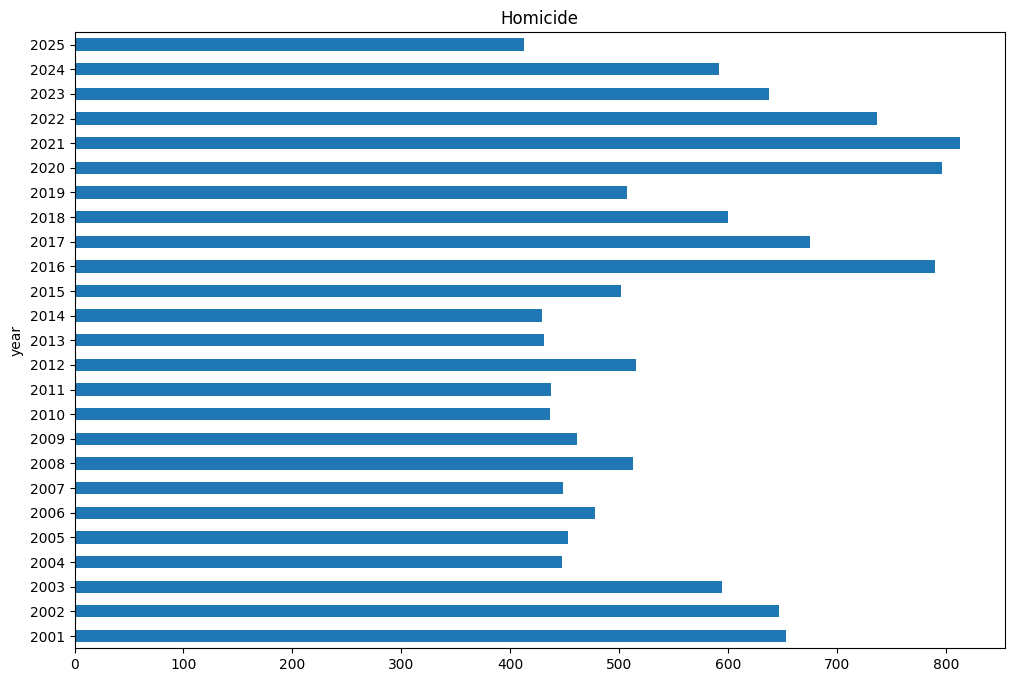

In [31]:
plt.figure(figsize=(12,8))
crime_per_year.HOMICIDE.plot(kind="barh")
plt.title("Homicide")
plt.show()

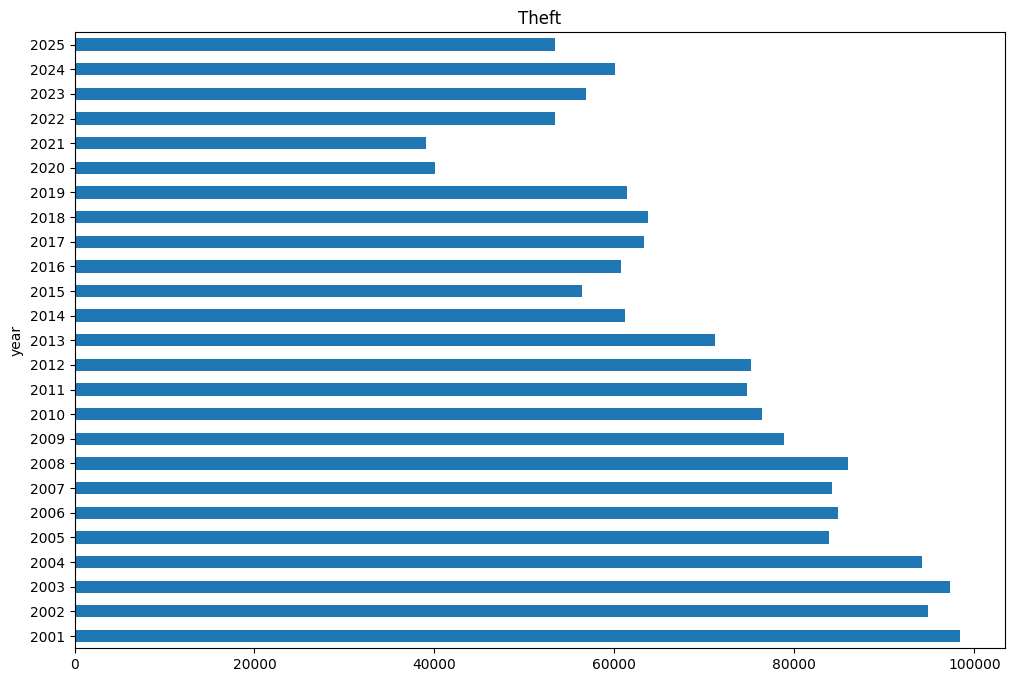

In [32]:
plt.figure(figsize=(12,8))
crime_per_year.THEFT.plot(kind="barh")
plt.title("Theft")
plt.show()

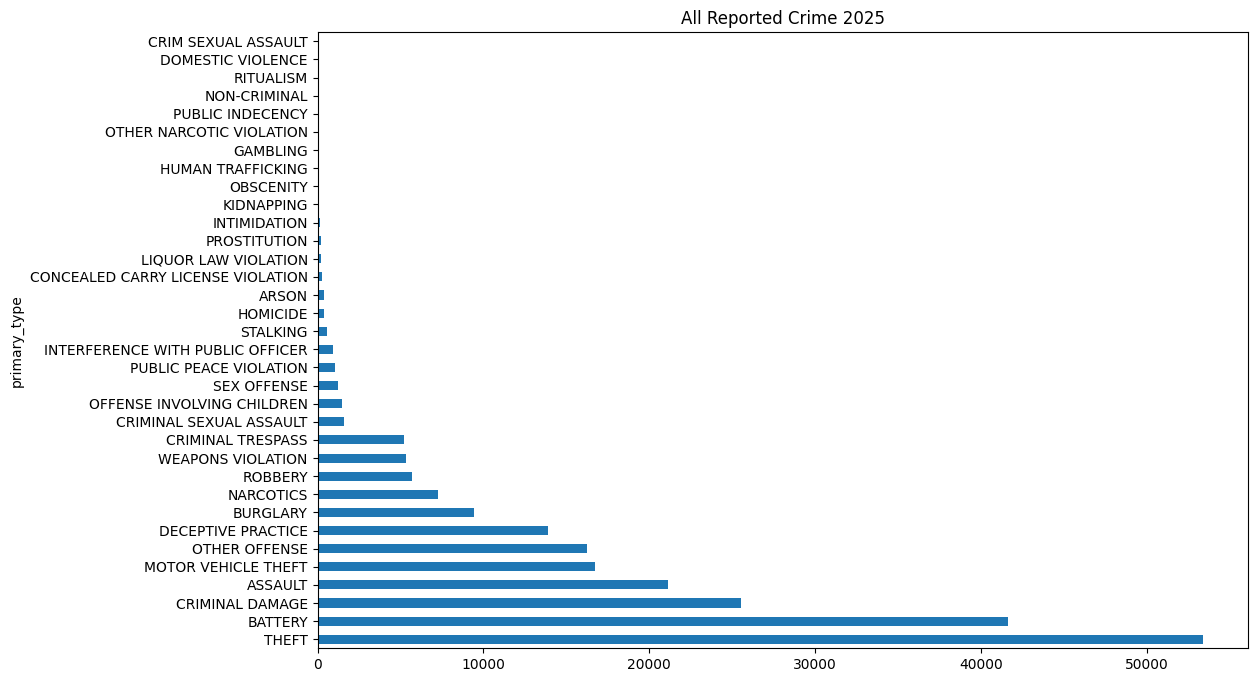

In [35]:
plt.figure(figsize=(12,8)) 
crime_per_year.loc[2025].sort_values(ascending=False).plot(kind="barh")
plt.title("All Reported Crime 2025")
plt.show()

## Consolidate Location

In [41]:
# by location
df_crime.location_description.value_counts().head(10)

location_description
STREET                            2194409
RESIDENCE                         1362014
APARTMENT                          995724
SIDEWALK                           758652
OTHER                              264270
PARKING LOT/GARAGE(NON.RESID.)     199569
ALLEY                              187004
SMALL RETAIL STORE                 168528
SCHOOL, PUBLIC, BUILDING           145398
RESTAURANT                         140797
Name: count, dtype: int64

In [48]:
df_crime.location_description.nunique()

219

In [47]:
df = 

df_crime.location_description[df_crime.location_description.str.contains('AIRPORT', case=False)]

24697       AIRPORT TERMINAL LOWER LEVEL - NON-SECURE AREA
60823                                  AIRPORT PARKING LOT
69950                                     AIRPORT/AIRCRAFT
70420                                  AIRPORT PARKING LOT
73907                                     AIRPORT/AIRCRAFT
142991                                    AIRPORT/AIRCRAFT
217607                 AIRPORT TRANSPORTATION SYSTEM (ATS)
301742                                 AIRPORT PARKING LOT
354711     AIRPORT BUILDING NON-TERMINAL - NON-SECURE AREA
451860                                 AIRPORT PARKING LOT
458284         AIRPORT BUILDING NON-TERMINAL - SECURE AREA
500742                                    AIRPORT/AIRCRAFT
500747          AIRPORT TERMINAL UPPER LEVEL - SECURE AREA
500751                                    AIRPORT/AIRCRAFT
500759                                    AIRPORT/AIRCRAFT
500761                                    AIRPORT/AIRCRAFT
500762                                    AIRPORT/AIRCRA

## Crime Data

In [27]:
df_crime[['year', 'zip_code', 'primary_neighborhood', 'arrest']].groupby(
    ['year', 'zip_code', 'primary_neighborhood']
).sum()

arrest
year zip_code primary_neighborhood                                                    
2001 60601    Loop                   tfffffffffffffffffffffffffffffffffffffftfffttf...
     60602    Loop                   fffffffffffffffffffffffftffffftfffffftffffffff...
              Millenium Park                      fffffffffffffftftfttfftttttfffffffff
     60603    Grant Park                                                    tfftffffft
              Loop                   ftftffffffffffftffffffffffffffffffffffffffffff...
              Millenium Park                                         ftttftffftftftfff
     60604    Grant Park             ffffftffffffffffftttftftffffffffffffftfttfffff...
              Loop                   fftfttttftttftftftftfftfttftttffffttttttffftff...
     60605    Grant Park             ftfffffffftffftftftttttttfttfftfffftttttttffft...
              Loop                   ffttffffffffffffffftffffffttttttftttfttttfffff...
              Museum Campus          ttftfffftfffftfftfttffftffttttftttftfffttffttt...
              Near South Side        fftftfftttttttffffftffftfffftftfffttffttffffff...
              Printers Row           fftfffffftfftffffffffttfftfffffffftfftfffftfff...
     60606    Loop                   tffffffffffftfffffffffffffffffffftffffffffffff...
              River North            ffffffffffftffffftfffffffffftffffffffftfffftff...
              West Loop              fffffffffttffffffffftftftfftfffffffffffftttfff...
     60607    Greektown              ffffttffffffttffftffffffftttfffffffffffffffftf...
              Little Italy, UIC      ffffftfftffffttttttttttttffftfftfffftttttttttt...
              Loop                   ffftffffftfffffffftfffffffttftfttfffttffffffff...
              West Loop              fffftffftffffffftffttfffffffffffffffffftffffff...
     60608    Bridgeport             ffttftttttftftftffffffffftffffttfftffftftftttf...
              Brighton Park                                         fffftffffffftfftff
              Little Italy, UIC      ffftftffttfffffttffffffffffffffffffffftfttfftt...
              Little Village         ftfffffffffftffftfftfttfffffffffffffffffffftft...
              Lower West Side        ffftfffffffffffffffffffftfffffffftfftfffffffft...
              Mckinley Park          fffffffffffffffffffffffffftttfttftftffftffffft...
              North Lawndale         fffffffffffffffttffftftffffttffffftttttttttfff...
     60609    Armour Square          fftttttttftfffffftttfffftftfttftttttttffttttff...
              Bridgeport             ffttftftfftftfftttfffffffffffffttffttfftfttftf...
              Brighton Park          fffffffffftttfftfftfffftffffffftfftftfftfffttf...
              Douglas                tttttttttttttttttttttttttttftttttfffftttftftff...
              Englewood                                         fffffftfffffftfttfffft
              Fuller Park            ttftfttttfttftffffttftfftfftffffffffffttffffff...
              Gage Park              ftttfffffftffffftfffffftffftfftftftftfttftffff...
              Grand Boulevard        tfffttffttfttttttfttftttttffftttttfftfffftfttt...
              Mckinley Park          ffftfftfffftffffffffftfftftfttttfftfffffffffff...
              New City               tftffffftftffffftttttffftfffttfftffffffffftfff...
              Washington Park        fftfftffffttfffftttfffftftffffffftttfttttfffff...
     60610    Gold Coast             tffffffffffffffffttftfffttfffffffftffftttffftf...
              Old Town               tffffffffffffffffffffffffftfftfftfffffffttttff...
              River North            ttttftffftttfffftttfffffffttttftfffftftttttttf...
              Rush & Division        ttffffttfffffffffffffffffftfffffffffffffftfftf...
              West Town                                                     ffffffffft
     60611    Gold Coast             ffftftffffffffffffffftffftftffffttfffttfffftff...
              Magnificent Mile       tftttttttttttfttffffffffffftttffftffftfff

In [20]:
import polars as pl
import pyarrow
print(pyarrow.__version__) 
print(pl.__version__) 

# 1. Convert pandas df to polars (if not already loaded in polars)
df_pl = pl.from_pandas(df_crime)

# 2. Perform the group_by and sum
df_summary = df_pl.group_by(['year','zip_code', 'primary_neighborhood']).agg([
    pl.col([pl.Int32, pl.Float64, pl.Int64]).sum()  # Numeric columns only
    # OR safer: count (works on everything)
    # pl.count().alias('crime_count')
])
df_summary

year,zip_code,primary_neighborhood,beat,district,ward,community_area,zip_code_area,neighborhood_area,p_district,p_sector,p_beat,p_beat_num
i64,i64,str,i64,f64,f64,f64,f64,f64,i64,i64,i64,i64
2024,60604,"""Loop""",88869,779.0,17888.0,24928.0,3.3457e9,2.4527e10,779,885,885,88982
2001,60649,"""Jackson Park""",80801,732.0,0.0,0.0,1.9648e10,5.7451e9,732,732,732,80764
2003,60620,"""Englewood""",80109,774.0,2193.0,8826.0,2.4528e10,2.2394e10,774,258,258,80109
2023,60614,"""Old Town""",965161,9576.0,14032.0,3769.0,5.0253e10,1.0559e10,9576,532,532,964810
2007,60639,"""Logan Square""",214539,2125.0,2613.0,1860.0,1.0835e10,6.0568e9,2125,170,170,214540
…,…,…,…,…,…,…,…,…,…,…,…,…
2017,60644,"""Garfield Park""",10017,99.0,252.0,226.0,8.9183e8,8.0978e8,99,9,9,10017
2002,60643,"""Beverly""",3476177,34536.0,23261.0,87468.0,3.2651e11,1.3956e11,34584,1893,1893,3480906
2024,60643,"""West Pullman""",555749,5319.0,19653.0,52901.0,2.0542e11,9.8272e10,4945,1978,1978,518143


In [20]:
# Joining df1_crime and df_arrest on a common column
df = pd.merge(df_crime, df_arrest, on='case_number', how='inner')
df.head()

,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,year,updated_on,zip_code,zip_code_area,primary_neighborhood,secondary_neighborhood,neighborhood_area,p_district,p_sector,p_beat,p_beat_num,cb_no,arrest_date,race,charge_1_statute,charge_1_description,charge_1_type,charge_1_class,charge_2_statute,charge_2_description,charge_2_type,charge_2_class,charge_3_statute,charge_3_description,charge_3_type,charge_3_class,charge_4_statute,charge_4_description,charge_4_type,charge_4_class,charges_statute,charges_description,charges_type,charges_class
0,JA503444,2017-11-08 07:15:00,004XX S WELLS ST,1330,CRIMINAL TRESPASS,TO LAND,BAR OR TAVERN,t,f,122,1.0,2.0,32.0,2017,2018-02-10 15:50:01,60607,6.466429e+07,Loop,LOOP,3.148519e+07,1,2,2,122,19560817,2017-11-08 07:25:00,WHITE HISPANIC,720 ILCS 5.0/21-3-A-1,CRIMINAL TRESPASS TO REAL PROPERTY,M,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,720 ILCS 5.0/21-3-A-1 | | |,CRIMINAL TRESPASS TO REAL PROPERTY | | |,M | | |,B | | |
1,JA189755,2017-03-16 22:15:00,004XX S WELLS ST,1330,CRIMINAL TRESPASS,TO LAND,BAR OR TAVERN,t,f,122,1.0,2.0,32.0,2017,2018-02-10 15:50:01,60607,6.466429e+07,Loop,LOOP,3.148519e+07,1,2,2,122,19451927,2017-03-16 21:22:00,BLACK,720 ILCS 5.0/21-3-A-2,CRIMINAL TRESPASS TO LAND,M,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,720 ILCS 5.0/21-3-A-2 | | |,CRIMINAL TRESPASS TO LAND | | |,M | | |,B | | |
2,HZ394345,2016-08-16 12:51:00,004XX S WELLS ST,0460,BATTERY,SIMPLE,RESTAURANT,t,f,122,1.0,2.0,32.0,2016,2018-02-10 15:50:01,60607,6.466429e+07,Loop,LOOP,3.148519e+07,1,2,2,122,19357112,2016-08-16 12:58:00,BLACK,720 ILCS 5.0/12-3-A-2,BATTERY - MAKE PHYSICAL CONTACT,M,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,720 ILCS 5.0/12-3-A-2 | | |,BATTERY - MAKE PHYSICAL CONTACT | | |,M | | |,A | | |
3,HZ215333,2016-04-06 09:21:00,004XX S WELLS ST,2170,NARCOTICS,POSSESSION OF DRUG EQUIPMENT,STREET,t,f,122,1.0,2.0,32.0,2016,2018-02-10 15:50:01,60607,6.466429e+07,Loop,LOOP,3.148519e+07,1,2,2,122,19290901,2016-04-06 09:40:00,BLACK,720 ILCS 600.0/3.5-A,PCS - DRUG PARAPHERNALIA - POSSESS,M,A,625 ILCS 5.0/6-303-A,DRIVING ON SUSPENDED LICENSE,M,A,625 ILCS 5.0/3-707,INSURANCE - OPERATE MTR VEHICLE WITHOUT,NaN,U,9-40-010,COMPLIANCE-REQUIRED,NaN,L,720 ILCS 600.0/3.5-A | 625 ILCS 5.0/6-303-A | ...,PCS - DRUG PARAPHERNALIA - POSSESS | DRIVING O...,M | M | |,A | A | U | L
4,JF427470,2022-10-09 01:57:00,004XX S WELLS ST,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,t,f,122,1.0,25.0,32.0,2022,2022-10-16 15:41:36,60607,6.466429e+07,Loop,LOOP,3.148519e+07,1,2,2,122,30184187,2022-10-09 01:53:00,BLACK,720 ILCS 5.0/9-1-A-1,MURDER - FIRST DEGREE,F,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,720 ILCS 5.0/9-1-A-1 | | |,MURDER - FIRST DEGREE | | |,F | | |,M | | |


In [24]:
df.arrest.value_counts(dropna=False)

arrest
t    395674
f     25426
Name: count, dtype: int64

In [ ]:
# df[(df['Primary Type'].str.contains('HOMICIDE', case=False, na=False)) & (df.Year == 2025)]
# # Crime type per year
# df.groupby([df.Year, 'Primary Type']).size().unstack(fill_value=0)

In [ ]:
# Simulate crime data: 3 neighborhood types (urban, suburban, rural), n=100 each
np.random.seed(1776)
urban = np.random.normal(45, 5, 100)      # High crime
suburban = np.random.normal(20, 4, 100)   # Medium
rural = np.random.normal(5, 2, 100)       # Low

df = pd.DataFrame({
    'burglaries': np.concatenate([urban, suburban, rural]),
    'neighborhood': np.repeat(['urban', 'suburban', 'rural'], 100)
})

df.head()

### Descriptives and Visualization

In [ ]:
# Summary stats by group
print(pg.descriptives('burglaries', data=df, groupby='neighborhood'))

In [ ]:
# Summary stats by group
print(pg.descriptives('burglaries', data=df, groupby='neighborhood'))

# Boxplot (reveals clear separation)
sns.boxplot(data=df, x='neighborhood', y='burglaries')
plt.title('Burglary Rates by Neighborhood Type')
plt.show()


In [ ]:
# Check Assumptions
# Normality
print('Normality Test:')
print(pg.normality(df, dv='burglaries', group='neighborhood'))

In [ ]:
# Variance
print("\nVariance Test:")
print(pg.homoscedasticity(df, dv='burglaries', group = 'neighborhood'))

In [ ]:
# Robust ANOVA (Welch's)
aov = pg.welch_anova(dv='burglaries', between='neighborhood', data = df)
print("\nWelch's ANOVA Rersults:")
print(aov)